# Auditoría de Gobernanza y Privacidad: Dataset SABER 11 (2020-2)

**Integrantes:** Agustín Figueroa Sierra, Samuel Aristizábal Alzate  
**Curso:** Gestión y Gobernanza de Datos  
**Dataset:** [Saber 11 2020-2](https://www.datos.gov.co/Educaci-n/Saber-11-2020-2/rnvb-vnyh/data_preview)  
**Fuente:** Instituto Colombiano para la Evaluación de la Educación (ICFES)

---

## Declaración de Apoyo de IA

* **Herramientas utilizadas:** Claude (Antigravity), GitHub Copilot.
* **Tareas realizadas con apoyo de IA:** Estructura del cuaderno, código de análisis de calidad, generación de regex para PII, código de k-anonymity, generación del glosario inicial, redacción de plantillas para el informe.
* **Tareas realizadas manualmente:** Definición de umbrales de calidad, clasificación de sensibilidad por columna, análisis de riesgos de re-identificación, selección de cuasi-identificadores, decisiones del plan de remediación, redacción final del informe PDF, verificación de cifras y hallazgos.

---

## Sección 0 · Setup y Carga de Datos

In [43]:
# Instalación de dependencias (descomentar si es necesario)
# !pip install pandas numpy matplotlib seaborn ydata-profiling

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
from collections import Counter

# Configuración general
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 85)
pd.set_option('display.max_colwidth', 50)

print("✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


In [44]:
# Carga del dataset
RUTA_CSV = 'Saber_11°_2020-2_20260512.csv'

df = pd.read_csv(RUTA_CSV, encoding='utf-8')

print(f"Dimensiones del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Memoria en uso: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head(3)

Dimensiones del dataset: 504,872 filas × 81 columnas
Memoria en uso: 633.9 MB


,ESTU_TIPODOCUMENTO,ESTU_NACIONALIDAD,ESTU_GENERO,ESTU_FECHANACIMIENTO,PERIODO,ESTU_CONSECUTIVO,ESTU_ESTUDIANTE,ESTU_PAIS_RESIDE,ESTU_TIENEETNIA,ESTU_DEPTO_RESIDE,ESTU_COD_RESIDE_DEPTO,ESTU_MCPIO_RESIDE,ESTU_COD_RESIDE_MCPIO,FAMI_ESTRATOVIVIENDA,FAMI_PERSONASHOGAR,FAMI_CUARTOSHOGAR,FAMI_EDUCACIONPADRE,FAMI_EDUCACIONMADRE,FAMI_TRABAJOLABORPADRE,FAMI_TRABAJOLABORMADRE,FAMI_TIENEINTERNET,FAMI_TIENESERVICIOTV,FAMI_TIENECOMPUTADOR,FAMI_TIENELAVADORA,FAMI_TIENEHORNOMICROOGAS,FAMI_TIENEAUTOMOVIL,FAMI_TIENEMOTOCICLETA,FAMI_TIENECONSOLAVIDEOJUEGOS,FAMI_NUMLIBROS,FAMI_COMELECHEDERIVADOS,FAMI_COMECARNEPESCADOHUEVO,FAMI_COMECEREALFRUTOSLEGUMBRE,FAMI_SITUACIONECONOMICA,ESTU_DEDICACIONLECTURADIARIA,ESTU_DEDICACIONINTERNET,ESTU_HORASSEMANATRABAJA,ESTU_TIPOREMUNERACION,COLE_CODIGO_ICFES,COLE_COD_DANE_ESTABLECIMIENTO,COLE_NOMBRE_ESTABLECIMIENTO,COLE_GENERO,COLE_NATURALEZA,COLE_CALENDARIO,COLE_BILINGUE,COLE_CARACTER,COLE_COD_DANE_SEDE,COLE_NOMBRE_SEDE,COLE_SEDE_PRINCIPAL,COLE_AREA_UBICACION,COLE_JORNADA,COLE_COD_MCPIO_UBICACION,COLE_MCPIO_UBICACION,COLE_COD_DEPTO_UBICACION,COLE_DEPTO_UBICACION,ESTU_PRIVADO_LIBERTAD,ESTU_COD_MCPIO_PRESENTACION,ESTU_MCPIO_PRESENTACION,ESTU_DEPTO_PRESENTACION,ESTU_COD_DEPTO_PRESENTACION,PUNT_LECTURA_CRITICA,PERCENTIL_LECTURA_CRITICA,DESEMP_LECTURA_CRITICA,PUNT_MATEMATICAS,PERCENTIL_MATEMATICAS,DESEMP_MATEMATICAS,PUNT_C_NATURALES,PERCENTIL_C_NATURALES,DESEMP_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PERCENTIL_SOCIALES_CIUDADANAS,DESEMP_SOCIALES_CIUDADANAS,PUNT_INGLES,PERCENTIL_INGLES,DESEMP_INGLES,PUNT_GLOBAL,PERCENTIL_GLOBAL,ESTU_INSE_INDIVIDUAL,ESTU_NSE_INDIVIDUAL,ESTU_NSE_ESTABLECIMIENTO,ESTU_ESTADOINVESTIGACION,ESTU_GENERACION-E
0,TI,SUIZA,F,2003 Mar 03 12:00:00 AM,20204,SB11202040211436,ESTUDIANTE,SUIZA,No,CUNDINAMARCA,25.0,CAJICÁ,25126.0,Estrato 2,5 a 6,Dos,Técnica o tecnológica completa,Educación profesional completa,Es operario de máquinas o conduce vehículos (t...,Es operario de máquinas o conduce vehículos (t...,Si,Si,Si,Si,No,No,Si,No,26 A 100 LIBROS,3 a 5 veces por semana,1 o 2 veces por semana,3 a 5 veces por semana,Peor,30 minutos o menos,Más de 3 horas,0,No,679225,225126000431,I. E. D. RURAL ANTONIO NARIÑO,MIXTO,OFICIAL,A,N,ACADÉMICO,225126000431,I. E. D. RURAL ANTONIO NARIÑO - SEDE PRINCIPAL,S,RURAL,UNICA,25126,CAJICÁ,25,CUNDINAMARCA,N,25126.0,CAJICÁ,CUNDINAMARCA,25.0,54,57,3,65,89,3,41,29,2,33,11,1,55.0,81,A1,244,49,"54,88236473511",3.0,3.0,PUBLICAR,NO
1,PEP,VENEZUELA,M,2002 May 10 12:00:00 AM,20204,SB11202040433216,ESTUDIANTE,VENEZUELA,No,CUNDINAMARCA,25.0,CAJICÁ,25126.0,Estrato 3,3 a 4,Uno,Secundaria (Bachillerato) completa,Educación profesional completa,Es vendedor o trabaja en atención al público,Es vendedor o trabaja en atención al público,Si,Si,No,No,No,No,No,No,0 A 10 LIBROS,3 a 5 veces por semana,Todos o casi todos los días,3 a 5 veces por semana,Mejor,No leo por entretenimiento,Más de 3 horas,Entre 11 y 20 horas,"Si, en efectivo",706085,225175000242,I.E. BOJACA,MIXTO,OFICIAL,A,N,ACADÉMICO,225175000242,I.E. BOJACA - SEDE PRINCIPAL,S,RURAL,NOCHE,25175,CHÍA,25,CUNDINAMARCA,N,25126.0,CAJICÁ,CUNDINAMARCA,25.0,57,67,3,43,26,2,46,45,2,49,55,2,33.0,6,A-,238,44,"49,2523109721",2.0,2.0,PUBLICAR,NO
2,TI,VENEZUELA,F,2003 Dec 14 12:00:00 AM,20204,SB11202040244180,ESTUDIANTE,VENEZUELA,No,CUNDINAMARCA,25.0,CAJICÁ,25126.0,Estrato 1,5 a 6,Uno,Primaria incompleta,Secundaria (Bachillerato) incompleta,"Es agricultor, pesquero o jornalero","Trabaja en el hogar, no trabaja o estudia",No,Si,No,Si,Si,No,Si,No,0 A 10 LIBROS,1 o 2 veces por semana,3 a 5 veces por semana,3 a 5 veces por semana,Igual,Entre 30 y 60 minutos,30 minutos o menos,0,"Si, en efectivo",679225,225126000431,I. E. D. RURAL ANTONIO NARIÑO,MIXTO,OFICIAL,A,N,ACADÉMICO,225126000431,I. E. D. RURAL ANTONIO NARIÑO - SEDE PRINCIPAL,S,RURAL,UNICA,25126,CAJICÁ,25,CUNDINAMARCA,N,25126.0,CAJICÁ,CUNDINAMARCA,25.0,59,73,3,72,97,4,63,92,3,68,95,3,59.0,87,A2,325,94,"40,73367237969",1.0,3.0,PUBLICAR,GENERACION E - GRATUIDAD


In [45]:
# Vista rápida de tipos de datos
print("Tipos de datos presentes:")
print(df.dtypes.value_counts())
print(f"\nColumnas numéricas: {df.select_dtypes(include='number').columns.tolist()}")
print(f"\nColumnas categóricas (object): {len(df.select_dtypes(include='object').columns)}")

Tipos de datos presentes:
str        53
int64      21
float64     7
Name: count, dtype: int64

Columnas numéricas: ['PERIODO', 'ESTU_COD_RESIDE_DEPTO', 'ESTU_COD_RESIDE_MCPIO', 'COLE_CODIGO_ICFES', 'COLE_COD_DANE_ESTABLECIMIENTO', 'COLE_COD_DANE_SEDE', 'COLE_COD_MCPIO_UBICACION', 'COLE_COD_DEPTO_UBICACION', 'ESTU_COD_MCPIO_PRESENTACION', 'ESTU_COD_DEPTO_PRESENTACION', 'PUNT_LECTURA_CRITICA', 'PERCENTIL_LECTURA_CRITICA', 'DESEMP_LECTURA_CRITICA', 'PUNT_MATEMATICAS', 'PERCENTIL_MATEMATICAS', 'DESEMP_MATEMATICAS', 'PUNT_C_NATURALES', 'PERCENTIL_C_NATURALES', 'DESEMP_C_NATURALES', 'PUNT_SOCIALES_CIUDADANAS', 'PERCENTIL_SOCIALES_CIUDADANAS', 'DESEMP_SOCIALES_CIUDADANAS', 'PUNT_INGLES', 'PERCENTIL_INGLES', 'PUNT_GLOBAL', 'PERCENTIL_GLOBAL', 'ESTU_NSE_INDIVIDUAL', 'ESTU_NSE_ESTABLECIMIENTO']

Columnas categóricas (object): 53


---
# Sección 1 · Ficha del Dataset

## 1.1 Dominio

| Campo | Descripción |
|-------|------------|
| **Dominio** | Educación — Pruebas de Estado |
| **Dataset** | Resultados Saber 11, periodo 2020-2 |
| **Fuente** | Instituto Colombiano para la Evaluación de la Educación (ICFES) |
| **Portal** | [datos.gov.co](https://www.datos.gov.co/Educaci-n/Saber-11-2020-2/rnvb-vnyh/data_preview) |
| **Periodo** | Segundo semestre de 2020 |
| **Granularidad** | Un registro por estudiante que presentó el examen |
| **Licencia** | Datos abiertos — Ley 1712 de 2014 (Transparencia y Acceso a la Información) |

## 1.2 Dueño Propuesto

| Rol | Responsable | Alcance de decisiones |
|-----|------------|----------------------|
| **Data Owner** | Subdirección de Estadísticas del ICFES | Define política de publicación, aprueba niveles de agregación, autoriza acceso a microdatos identificados, establece periodos de retención |
| **Data Steward** | Equipo de Gestión de Información del ICFES | Garantiza calidad de los datos, mantiene el diccionario de datos, aplica reglas de anonimización |
| **Data Custodian** | Oficina de Tecnología del ICFES | Almacenamiento seguro, respaldos, control de acceso técnico, infraestructura |

> **Justificación (DAMA-DMBOK2):** El Data Owner es la autoridad de negocio con poder de decisión sobre los datos. En el caso del ICFES, la Subdirección de Estadísticas es quien define qué se publica y bajo qué condiciones, alineado con el rol descrito en el capítulo de Data Governance del DMBOK2.

## 1.3 Glosario de Términos Clave

| # | Término | Definición |
|---|---------|-----------|
| 1 | **ICFES** | Instituto Colombiano para la Evaluación de la Educación. Entidad adscrita al Ministerio de Educación Nacional, responsable de las pruebas de Estado. |
| 2 | **SABER 11** | Examen de Estado que deben presentar los estudiantes de grado 11 como requisito para acceder a la educación superior en Colombia. |
| 3 | **SNP** | Sistema Nacional de Pruebas. Marco institucional que agrupa las evaluaciones estandarizadas del ICFES (Saber 3°, 5°, 9°, 11°, Saber Pro). |
| 4 | **Estrato socioeconómico** | Clasificación de 1 (más bajo) a 6 (más alto) de las viviendas en Colombia, utilizada para focalizar subsidios y tarifas de servicios públicos. |
| 5 | **INSE** | Índice de Nivel Socioeconómico del Estudiante. Variable continua calculada por el ICFES a partir de las condiciones del hogar. |
| 6 | **NSE** | Nivel Socioeconómico. Categorización ordinal (1 a 4) derivada del INSE. |
| 7 | **Código DANE** | Identificador numérico único asignado por el DANE a cada entidad territorial y establecimiento educativo en Colombia. |
| 8 | **Código ICFES** | Identificador numérico asignado por el ICFES a cada establecimiento educativo registrado en el sistema de pruebas. |
| 9 | **Cuasi-identificador (QID)** | Atributo que por sí solo no identifica a una persona, pero en combinación con otros puede permitir la re-identificación. |
| 10 | **k-anonymity** | Propiedad de privacidad que garantiza que cada combinación de cuasi-identificadores aparece en al menos *k* registros del dataset. |
| 11 | **PII** | *Personally Identifiable Information*. Cualquier dato que permite identificar directa o indirectamente a una persona natural. |
| 12 | **ESTU_CONSECUTIVO** | Código alfanumérico interno del ICFES que identifica unívocamente a cada inscrito en una aplicación del examen. |

## 1.4 Esquema del Dataset con Tipos

In [46]:
# Construcción del esquema tipado del dataset
esquema = pd.DataFrame({
    'Columna': df.columns,
    'Tipo_Pandas': df.dtypes.astype(str).values,
    'Nulos': df.isnull().sum().values,
    'Pct_Nulos': (df.isnull().sum() / len(df) * 100).round(2).values,
    'Valores_Unicos': df.nunique().values,
    'Ejemplo': [str(df[c].dropna().iloc[0])[:50] if df[c].notna().any() else 'N/A' for c in df.columns]
})

# Clasificación semántica de tipo de variable
def clasificar_tipo(col):
    if col in ['PUNT_LECTURA_CRITICA', 'PUNT_MATEMATICAS', 'PUNT_C_NATURALES',
                'PUNT_SOCIALES_CIUDADANAS', 'PUNT_INGLES', 'PUNT_GLOBAL',
                'PERCENTIL_LECTURA_CRITICA', 'PERCENTIL_MATEMATICAS',
                'PERCENTIL_C_NATURALES', 'PERCENTIL_SOCIALES_CIUDADANAS',
                'PERCENTIL_INGLES', 'PERCENTIL_GLOBAL', 'ESTU_INSE_INDIVIDUAL']:
        return 'Numérica continua'
    elif col.startswith('DESEMP_') or col in ['ESTU_NSE_INDIVIDUAL', 'ESTU_NSE_ESTABLECIMIENTO']:
        return 'Categórica ordinal'
    elif col in ['ESTU_CONSECUTIVO', 'COLE_CODIGO_ICFES', 'COLE_COD_DANE_ESTABLECIMIENTO',
                 'COLE_COD_DANE_SEDE', 'COLE_COD_MCPIO_UBICACION', 'COLE_COD_DEPTO_UBICACION',
                 'ESTU_COD_RESIDE_DEPTO', 'ESTU_COD_RESIDE_MCPIO',
                 'ESTU_COD_MCPIO_PRESENTACION', 'ESTU_COD_DEPTO_PRESENTACION']:
        return 'Identificador / Código'
    else:
        return 'Categórica nominal'

esquema['Tipo_Semantico'] = esquema['Columna'].apply(clasificar_tipo)

print(f"Total de columnas: {len(esquema)}")
print(f"\nDistribución por tipo semántico:")
print(esquema['Tipo_Semantico'].value_counts().to_string())
print()
esquema

Total de columnas: 81

Distribución por tipo semántico:
Tipo_Semantico
Categórica nominal        51
Numérica continua         13
Identificador / Código    10
Categórica ordinal         7



,Columna,Tipo_Pandas,Nulos,Pct_Nulos,Valores_Unicos,Ejemplo,Tipo_Semantico
0,ESTU_TIPODOCUMENTO,str,0,0.00,11,TI,Categórica nominal
1,ESTU_NACIONALIDAD,str,0,0.00,47,SUIZA,Categórica nominal
2,ESTU_GENERO,str,8,0.00,2,F,Categórica nominal
3,ESTU_FECHANACIMIENTO,str,0,0.00,9603,2003 Mar 03 12:00:00 AM,Categórica nominal
4,PERIODO,int64,0,0.00,1,20204,Categórica nominal
...,...,...,...,...,...,...,...
76,ESTU_INSE_INDIVIDUAL,str,13945,2.76,455002,"54,88236473511",Numérica continua
77,ESTU_NSE_INDIVIDUAL,float64,13945,2.76,4,3.0,Categórica ordinal
78,ESTU_NSE_ESTABLECIMIENTO,float64,49,0.01,4,3.0,Categórica ordinal
79,ESTU_ESTADOINVESTIGACION,str,0,0.00,2,PUBLICAR,Categórica nominal


---
# Sección 2 · Calidad del Dataset

Evaluación bajo cinco dimensiones: **completitud, unicidad, validez, consistencia y oportunidad**.

## 2.1 Completitud

Porcentaje de valores nulos por columna. **Umbral definido:** columnas con >5% de nulos requieren documentación y justificación.

In [47]:
# --- 2.1 COMPLETITUD ---
completitud = pd.DataFrame({
    'columna': df.columns,
    'nulos': df.isnull().sum().values,
    'pct_nulos': (df.isnull().sum() / len(df) * 100).round(2).values,
    'no_nulos': df.notnull().sum().values
}).sort_values('pct_nulos', ascending=False)

# Resumen
total_celdas = df.shape[0] * df.shape[1]
total_nulos = df.isnull().sum().sum()
print(f"Total de celdas en el dataset: {total_celdas:,}")
print(f"Total de valores nulos: {total_nulos:,} ({total_nulos/total_celdas*100:.2f}%)")
print(f"Columnas con algun nulo: {(completitud['nulos'] > 0).sum()}")
print(f"Columnas con >5% nulos: {(completitud['pct_nulos'] > 5).sum()}")
print()
completitud[completitud['nulos'] > 0]

Total de celdas en el dataset: 40,894,632
Total de valores nulos: 519,164 (1.27%)
Columnas con algun nulo: 40
Columnas con >5% nulos: 1



,columna,nulos,pct_nulos,no_nulos
43,COLE_BILINGUE,83007,16.44,421865
31,FAMI_COMECEREALFRUTOSLEGUMBRE,20263,4.01,484609
22,FAMI_TIENECOMPUTADOR,20194,4.00,484678
18,FAMI_TRABAJOLABORPADRE,19691,3.90,485181
25,FAMI_TIENEAUTOMOVIL,17809,3.53,487063
36,ESTU_TIPOREMUNERACION,17646,3.50,487226
19,FAMI_TRABAJOLABORMADRE,17599,3.49,487273
27,FAMI_TIENECONSOLAVIDEOJUEGOS,17478,3.46,487394
24,FAMI_TIENEHORNOMICROOGAS,17142,3.40,487730
26,FAMI_TIENEMOTOCICLETA,17086,3.38,487786


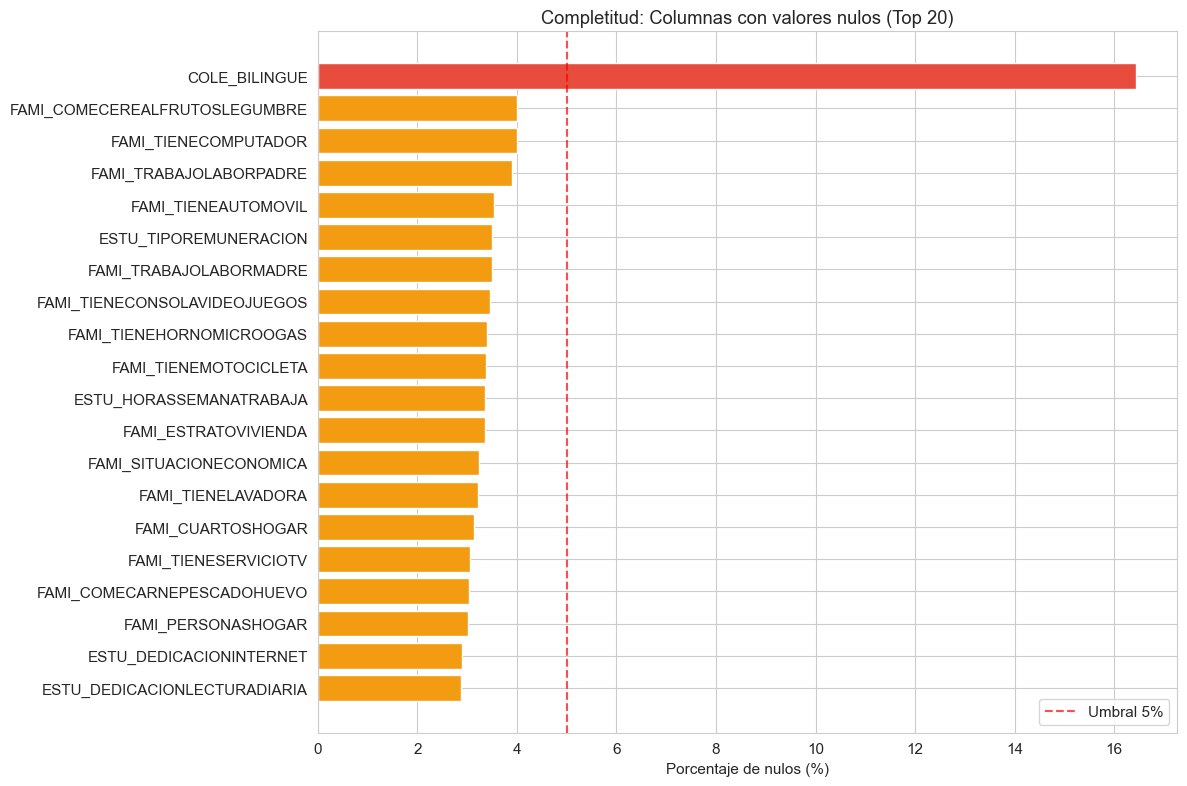

In [48]:
# Gráfico de completitud - Top 20 columnas con más nulos
cols_con_nulos = completitud[completitud['nulos'] > 0].head(20)

if len(cols_con_nulos) > 0:
    fig, ax = plt.subplots(figsize=(12, max(6, len(cols_con_nulos)*0.4)))
    bars = ax.barh(cols_con_nulos['columna'], cols_con_nulos['pct_nulos'],
                   color=cols_con_nulos['pct_nulos'].apply(
                       lambda x: '#e74c3c' if x > 5 else '#f39c12' if x > 1 else '#2ecc71'))
    ax.set_xlabel('Porcentaje de nulos (%)')
    ax.set_title('Completitud: Columnas con valores nulos (Top 20)')
    ax.axvline(x=5, color='red', linestyle='--', alpha=0.7, label='Umbral 5%')
    ax.legend()
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("No hay columnas con valores nulos.")

## 2.2 Unicidad

Verificación de registros duplicados completos y por identificador único (`ESTU_CONSECUTIVO`).

In [49]:
# --- 2.2 UNICIDAD ---
dup_completos = df.duplicated().sum()
dup_consecutivo = df['ESTU_CONSECUTIVO'].duplicated().sum()

print(f"Registros duplicados (todas las columnas): {dup_completos:,}")
print(f"Duplicados por ESTU_CONSECUTIVO: {dup_consecutivo:,}")
print(f"Valores unicos de ESTU_CONSECUTIVO: {df['ESTU_CONSECUTIVO'].nunique():,} de {len(df):,}")

if dup_consecutivo > 0:
    print(f"\n[!] Se encontraron {dup_consecutivo} registros con ESTU_CONSECUTIVO duplicado.")
    print("Ejemplos de duplicados:")
    dups = df[df['ESTU_CONSECUTIVO'].duplicated(keep=False)].sort_values('ESTU_CONSECUTIVO')
    print(dups[['ESTU_CONSECUTIVO','ESTU_GENERO','COLE_NOMBRE_ESTABLECIMIENTO','PUNT_GLOBAL']].head(10))
else:
    print("\n[OK] No hay duplicados por ESTU_CONSECUTIVO. Cada registro es unico.")

Registros duplicados (todas las columnas): 0
Duplicados por ESTU_CONSECUTIVO: 0
Valores unicos de ESTU_CONSECUTIVO: 504,872 de 504,872

[OK] No hay duplicados por ESTU_CONSECUTIVO. Cada registro es unico.


## 2.3 Validez

Conformidad de los datos con formatos y rangos esperados.

In [50]:
# --- 2.3 VALIDEZ ---
print("=" * 60)
print("VERIFICACION DE VALIDEZ")
print("=" * 60)

# 2.3.1 Estratos validos
estratos_validos = ['Estrato 1','Estrato 2','Estrato 3','Estrato 4','Estrato 5','Estrato 6','Sin Estrato']
estratos_reales = df['FAMI_ESTRATOVIVIENDA'].dropna().unique()
estratos_invalidos = [e for e in estratos_reales if e not in estratos_validos]
print(f"\n1. FAMI_ESTRATOVIVIENDA:")
print(f"   Valores encontrados: {sorted(estratos_reales)}")
print(f"   Valores invalidos: {estratos_invalidos if estratos_invalidos else 'Ninguno'}")

# 2.3.2 Genero
print(f"\n2. ESTU_GENERO:")
print(f"   Valores: {df['ESTU_GENERO'].value_counts().to_dict()}")

# 2.3.3 Puntajes en rango 0-100 (por area)
print(f"\n3. Rango de puntajes por area (esperado 0-100):")
punt_cols = ['PUNT_LECTURA_CRITICA','PUNT_MATEMATICAS','PUNT_C_NATURALES',
             'PUNT_SOCIALES_CIUDADANAS','PUNT_INGLES']
for col in punt_cols:
    s = pd.to_numeric(df[col], errors='coerce')
    fuera = ((s < 0) | (s > 100)).sum()
    print(f"   {col}: min={s.min()}, max={s.max()}, fuera de rango={fuera}")

# 2.3.4 Puntaje global (esperado 0-500)
pg = pd.to_numeric(df['PUNT_GLOBAL'], errors='coerce')
fuera_g = ((pg < 0) | (pg > 500)).sum()
print(f"\n4. PUNT_GLOBAL: min={pg.min()}, max={pg.max()}, fuera de rango (0-500)={fuera_g}")

# 2.3.5 Codigos DANE de municipio (5 digitos, normalizados con zfill)
print(f"\n5. Codigos DANE de municipio (COLE_COD_MCPIO_UBICACION):")
cod_m = df['COLE_COD_MCPIO_UBICACION'].dropna().astype(int).astype(str).str.zfill(5)
largo_invalido = cod_m[cod_m.str.len() != 5]
print(f"   Total: {len(cod_m):,}, con largo != 5 digitos (post-normalizacion): {len(largo_invalido):,}")
# Verificar que los primeros 2 digitos correspondan a un departamento valido (01-99)
deptos = cod_m.str[:2].astype(int)
print(f"   Rango de codigos de departamento extraidos: {deptos.min()} - {deptos.max()}")
print(f"   Departamentos unicos: {deptos.nunique()}")

VERIFICACION DE VALIDEZ

1. FAMI_ESTRATOVIVIENDA:
   Valores encontrados: ['Estrato 1', 'Estrato 2', 'Estrato 3', 'Estrato 4', 'Estrato 5', 'Estrato 6', 'Sin Estrato']
   Valores invalidos: Ninguno

2. ESTU_GENERO:
   Valores: {'F': 276572, 'M': 228292}

3. Rango de puntajes por area (esperado 0-100):
   PUNT_LECTURA_CRITICA: min=0, max=100, fuera de rango=0
   PUNT_MATEMATICAS: min=0, max=100, fuera de rango=0
   PUNT_C_NATURALES: min=0, max=100, fuera de rango=0
   PUNT_SOCIALES_CIUDADANAS: min=0, max=100, fuera de rango=0
   PUNT_INGLES: min=0.0, max=100.0, fuera de rango=0

4. PUNT_GLOBAL: min=0, max=500, fuera de rango (0-500)=0

5. Codigos DANE de municipio (COLE_COD_MCPIO_UBICACION):
   Total: 504,872, con largo != 5 digitos (post-normalizacion): 0
   Rango de codigos de departamento extraidos: 5 - 99
   Departamentos unicos: 33


## 2.4 Consistencia

Relaciones lógicas entre variables.

In [51]:
# --- 2.4 CONSISTENCIA ---
print("=" * 60)
print("VERIFICACION DE CONSISTENCIA")
print("=" * 60)

# 2.4.1 Municipio vs Departamento del colegio (normalizado con zfill)
print("\n1. Coherencia municipio-departamento del colegio:")
cod_mcpio_norm = df['COLE_COD_MCPIO_UBICACION'].dropna().astype(int).astype(str).str.zfill(5)
cod_depto_desde_mcpio = cod_mcpio_norm.str[:2]
cod_depto_real = df.loc[cod_mcpio_norm.index, 'COLE_COD_DEPTO_UBICACION'].astype(int).astype(str).str.zfill(2)
incoherentes_geo = (cod_depto_desde_mcpio != cod_depto_real).sum()
print(f"   Registros donde el depto del municipio no coincide con COLE_COD_DEPTO: {incoherentes_geo:,}")

# 2.4.2 Edad coherente con periodo 2020
print("\n2. Edad de los estudiantes al momento del examen (2020):")
fecha_nac = pd.to_datetime(df['ESTU_FECHANACIMIENTO'], errors='coerce')
edad_aprox = 2020 - fecha_nac.dt.year
edad_stats = edad_aprox.describe()
menores_14 = (edad_aprox < 14).sum()
mayores_25 = (edad_aprox > 25).sum()
print(f"   Edad promedio: {edad_stats['mean']:.1f}, min: {edad_stats['min']:.0f}, max: {edad_stats['max']:.0f}")
print(f"   Menores de 14: {menores_14:,} | Mayores de 25: {mayores_25:,}")
if edad_stats['min'] < 0 or edad_stats['max'] > 100:
    print(f"   [!] Se detectan edades anomalas (min={edad_stats['min']:.0f}, max={edad_stats['max']:.0f})")
    print(f"       Esto puede indicar errores en ESTU_FECHANACIMIENTO para algunos registros.")

# 2.4.3 PUNT_GLOBAL vs puntajes por area
print("\n3. PUNT_GLOBAL vs puntajes por area:")
punt_areas = ['PUNT_LECTURA_CRITICA','PUNT_MATEMATICAS','PUNT_C_NATURALES',
              'PUNT_SOCIALES_CIUDADANAS','PUNT_INGLES']
df_num = df[punt_areas + ['PUNT_GLOBAL']].apply(pd.to_numeric, errors='coerce')
df_num['_suma'] = df_num[punt_areas].sum(axis=1)
df_num['_diff'] = abs(df_num['_suma'] - df_num['PUNT_GLOBAL'])
print(f"   Diferencia promedio (suma areas - global): {df_num['_diff'].mean():.2f}")
print(f"   Nota: PUNT_GLOBAL NO es la suma aritmetica de las 5 areas.")
print(f"   El ICFES utiliza una formula de ponderacion propia para calcular")
print(f"   el puntaje global. La diferencia observada es consistente con")
print(f"   esta metodologia y NO representa un error de consistencia.")
corr = df_num[['_suma', 'PUNT_GLOBAL']].corr().iloc[0,1]
print(f"   Correlacion entre suma de areas y PUNT_GLOBAL: {corr:.4f}")

VERIFICACION DE CONSISTENCIA

1. Coherencia municipio-departamento del colegio:
   Registros donde el depto del municipio no coincide con COLE_COD_DEPTO: 0

2. Edad de los estudiantes al momento del examen (2020):
   Edad promedio: 17.6, min: -10, max: 825
   Menores de 14: 310 | Mayores de 25: 7,929
   [!] Se detectan edades anomalas (min=-10, max=825)
       Esto puede indicar errores en ESTU_FECHANACIMIENTO para algunos registros.

3. PUNT_GLOBAL vs puntajes por area:
   Diferencia promedio (suma areas - global): 4.39
   Nota: PUNT_GLOBAL NO es la suma aritmetica de las 5 areas.
   El ICFES utiliza una formula de ponderacion propia para calcular
   el puntaje global. La diferencia observada es consistente con
   esta metodologia y NO representa un error de consistencia.
   Correlacion entre suma de areas y PUNT_GLOBAL: 0.9939


## 2.5 Oportunidad

### Análisis de Oportunidad

| Aspecto | Evaluación |
|---------|-----------|
| **Periodo del dataset** | 2020-2 (segundo semestre) |
| **Antigüedad** | ~6 años al momento de este análisis (2026) |
| **Relevancia actual** | **Media-Alta** para análisis de tendencias, estudios de equidad y políticas educativas históricas |
| **Limitación** | No refleja cambios curriculares post-pandemia ni ajustes en la modalidad del examen |
| **Frecuencia de actualización** | El ICFES publica resultados semestralmente con ~6-12 meses de rezago |
| **Valor para gobernanza** | **Alto** — los principios de privacidad y calidad aplican independientemente de la antigüedad |

> **Conclusión:** Aunque el dataset tiene 6 años de antigüedad, sigue siendo relevante para el propósito de esta auditoría de gobernanza. Los riesgos de privacidad no caducan: un estudiante re-identificable en 2020 sigue siendo re-identificable hoy.

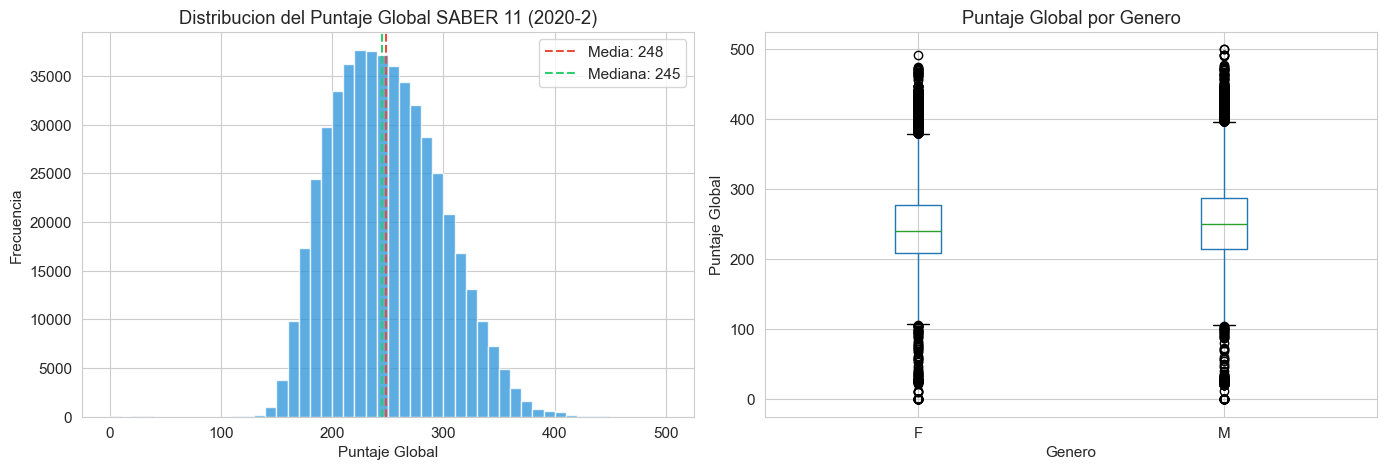


Estadisticas del puntaje global:
count    504872.0
mean        248.3
std          48.7
min           0.0
25%         211.0
50%         245.0
75%         282.0
max         500.0
Name: PUNT_GLOBAL, dtype: float64


In [52]:
# Gráfico de distribución de puntaje global para validar normalidad
punt_g = pd.to_numeric(df['PUNT_GLOBAL'], errors='coerce').dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(punt_g, bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(punt_g.mean(), color='#e74c3c', linestyle='--', label=f'Media: {punt_g.mean():.0f}')
axes[0].axvline(punt_g.median(), color='#2ecc71', linestyle='--', label=f'Mediana: {punt_g.median():.0f}')
axes[0].set_xlabel('Puntaje Global')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribucion del Puntaje Global SABER 11 (2020-2)')
axes[0].legend()

# Boxplot por genero
df_box = df[['ESTU_GENERO', 'PUNT_GLOBAL']].copy()
df_box['PUNT_GLOBAL'] = pd.to_numeric(df_box['PUNT_GLOBAL'], errors='coerce')
df_box.dropna(inplace=True)
df_box.boxplot(column='PUNT_GLOBAL', by='ESTU_GENERO', ax=axes[1])
axes[1].set_title('Puntaje Global por Genero')
axes[1].set_xlabel('Genero')
axes[1].set_ylabel('Puntaje Global')
plt.suptitle('')

plt.tight_layout()
plt.show()

print(f"\nEstadisticas del puntaje global:")
print(punt_g.describe().round(1))

---
# Sección 3 · Sensibilidad y PII

Clasificación de cada columna según su nivel de sensibilidad y detección automática de información personal identificable (PII).

## 3.1 Clasificación por Columna

Niveles de clasificación según la Ley 1581 de 2012 (Protección de Datos Personales):

| Nivel | Criterio | Color |
|-------|---------|-------|
| **Pública** | No identifica, no es sensible. Puede publicarse libremente | Verde |
| **Interna** | Útil para gestión, no se publica sin agregación | Amarillo |
| **Confidencial** | Dato personal no sensible (Art. 3, Ley 1581) | Naranja |
| **Restringida** | Identificador directo o dato sensible (Art. 5, Ley 1581) | Rojo |

In [53]:
# --- 3.1 CLASIFICACION DE SENSIBILIDAD POR COLUMNA ---
clasificacion = {
    # --- IDENTIFICADORES DIRECTOS (Restringida) ---
    'ESTU_CONSECUTIVO': 'Restringida',       # Identificador unico del estudiante
    'ESTU_ESTUDIANTE': 'Restringida',         # Indicador de rol
    'ESTU_FECHANACIMIENTO': 'Restringida',    # Fecha exacta de nacimiento
    'ESTU_TIENEETNIA': 'Restringida',         # Dato sensible (Art. 5, Ley 1581)
    'COLE_COD_DANE_SEDE': 'Restringida',      # Combinado con otros, identifica
    'ESTU_PRIVADO_LIBERTAD': 'Restringida',   # Condicion juridica sensible
    
    # --- DATOS PERSONALES NO SENSIBLES (Confidencial) ---
    'ESTU_TIPODOCUMENTO': 'Confidencial',
    'ESTU_NACIONALIDAD': 'Confidencial',
    'ESTU_GENERO': 'Confidencial',
    'ESTU_PAIS_RESIDE': 'Confidencial',
    'ESTU_DEPTO_RESIDE': 'Confidencial',
    'ESTU_COD_RESIDE_DEPTO': 'Confidencial',
    'ESTU_MCPIO_RESIDE': 'Confidencial',
    'ESTU_COD_RESIDE_MCPIO': 'Confidencial',
    'FAMI_ESTRATOVIVIENDA': 'Confidencial',
    'FAMI_PERSONASHOGAR': 'Confidencial',
    'FAMI_CUARTOSHOGAR': 'Confidencial',
    'FAMI_EDUCACIONPADRE': 'Confidencial',
    'FAMI_EDUCACIONMADRE': 'Confidencial',
    'FAMI_TRABAJOLABORPADRE': 'Confidencial',
    'FAMI_TRABAJOLABORMADRE': 'Confidencial',
    'FAMI_TIENEINTERNET': 'Confidencial',
    'FAMI_TIENESERVICIOTV': 'Confidencial',
    'FAMI_TIENECOMPUTADOR': 'Confidencial',
    'FAMI_TIENELAVADORA': 'Confidencial',
    'FAMI_TIENEHORNOMICROOGAS': 'Confidencial',
    'FAMI_TIENEAUTOMOVIL': 'Confidencial',
    'FAMI_TIENEMOTOCICLETA': 'Confidencial',
    'FAMI_TIENECONSOLAVIDEOJUEGOS': 'Confidencial',
    'FAMI_NUMLIBROS': 'Confidencial',
    'FAMI_COMELECHEDERIVADOS': 'Confidencial',
    'FAMI_COMECARNEPESCADOHUEVO': 'Confidencial',
    'FAMI_COMECEREALFRUTOSLEGUMBRE': 'Confidencial',
    'FAMI_SITUACIONECONOMICA': 'Confidencial',
    'ESTU_DEDICACIONLECTURADIARIA': 'Confidencial',
    'ESTU_DEDICACIONINTERNET': 'Confidencial',
    'ESTU_HORASSEMANATRABAJA': 'Confidencial',
    'ESTU_TIPOREMUNERACION': 'Confidencial',
    'ESTU_COD_MCPIO_PRESENTACION': 'Confidencial',
    'ESTU_MCPIO_PRESENTACION': 'Confidencial',
    'ESTU_DEPTO_PRESENTACION': 'Confidencial',
    'ESTU_COD_DEPTO_PRESENTACION': 'Confidencial',
    
    # --- DATOS INTERNOS (Interna) ---
    'PUNT_LECTURA_CRITICA': 'Interna',
    'PERCENTIL_LECTURA_CRITICA': 'Interna',
    'DESEMP_LECTURA_CRITICA': 'Interna',
    'PUNT_MATEMATICAS': 'Interna',
    'PERCENTIL_MATEMATICAS': 'Interna',
    'DESEMP_MATEMATICAS': 'Interna',
    'PUNT_C_NATURALES': 'Interna',
    'PERCENTIL_C_NATURALES': 'Interna',
    'DESEMP_C_NATURALES': 'Interna',
    'PUNT_SOCIALES_CIUDADANAS': 'Interna',
    'PERCENTIL_SOCIALES_CIUDADANAS': 'Interna',
    'DESEMP_SOCIALES_CIUDADANAS': 'Interna',
    'PUNT_INGLES': 'Interna',
    'PERCENTIL_INGLES': 'Interna',
    'DESEMP_INGLES': 'Interna',
    'PUNT_GLOBAL': 'Interna',
    'PERCENTIL_GLOBAL': 'Interna',
    'ESTU_INSE_INDIVIDUAL': 'Interna',
    'ESTU_NSE_INDIVIDUAL': 'Interna',
    'ESTU_NSE_ESTABLECIMIENTO': 'Interna',
    'ESTU_ESTADOINVESTIGACION': 'Interna',
    'ESTU_GENERACION-E': 'Interna',
    'COLE_CODIGO_ICFES': 'Interna',
    'COLE_COD_DANE_ESTABLECIMIENTO': 'Interna',
    'COLE_NOMBRE_SEDE': 'Interna',
    'COLE_SEDE_PRINCIPAL': 'Interna',
    
    # --- DATOS PUBLICOS (Publica) ---
    'PERIODO': 'Publica',
    'COLE_NOMBRE_ESTABLECIMIENTO': 'Publica',
    'COLE_GENERO': 'Publica',
    'COLE_NATURALEZA': 'Publica',
    'COLE_CALENDARIO': 'Publica',
    'COLE_BILINGUE': 'Publica',
    'COLE_CARACTER': 'Publica',
    'COLE_AREA_UBICACION': 'Publica',
    'COLE_JORNADA': 'Publica',
    'COLE_COD_MCPIO_UBICACION': 'Publica',
    'COLE_MCPIO_UBICACION': 'Publica',
    'COLE_COD_DEPTO_UBICACION': 'Publica',
    'COLE_DEPTO_UBICACION': 'Publica',
}

# Construir tabla de clasificacion
clasif_df = pd.DataFrame([
    {'Columna': col, 'Clasificacion': clasif}
    for col, clasif in clasificacion.items()
])

# Resumen
print("RESUMEN DE CLASIFICACION DE SENSIBILIDAD")
print("=" * 50)
resumen = clasif_df['Clasificacion'].value_counts()
for nivel in ['Restringida', 'Confidencial', 'Interna', 'Publica']:
    if nivel in resumen.index:
        print(f"  {nivel}: {resumen[nivel]} columnas")
print(f"  Total clasificadas: {len(clasif_df)} de {len(df.columns)}")

# Verificar columnas sin clasificar
sin_clasif = [c for c in df.columns if c not in clasificacion]
if sin_clasif:
    print(f"\n[!] Columnas sin clasificar: {sin_clasif}")
print()
clasif_df

RESUMEN DE CLASIFICACION DE SENSIBILIDAD
  Restringida: 6 columnas
  Confidencial: 36 columnas
  Interna: 26 columnas
  Publica: 13 columnas
  Total clasificadas: 81 de 81



,Columna,Clasificacion
0,ESTU_CONSECUTIVO,Restringida
1,ESTU_ESTUDIANTE,Restringida
2,ESTU_FECHANACIMIENTO,Restringida
3,ESTU_TIENEETNIA,Restringida
4,COLE_COD_DANE_SEDE,Restringida
...,...,...
76,COLE_JORNADA,Publica
77,COLE_COD_MCPIO_UBICACION,Publica
78,COLE_MCPIO_UBICACION,Publica
79,COLE_COD_DEPTO_UBICACION,Publica


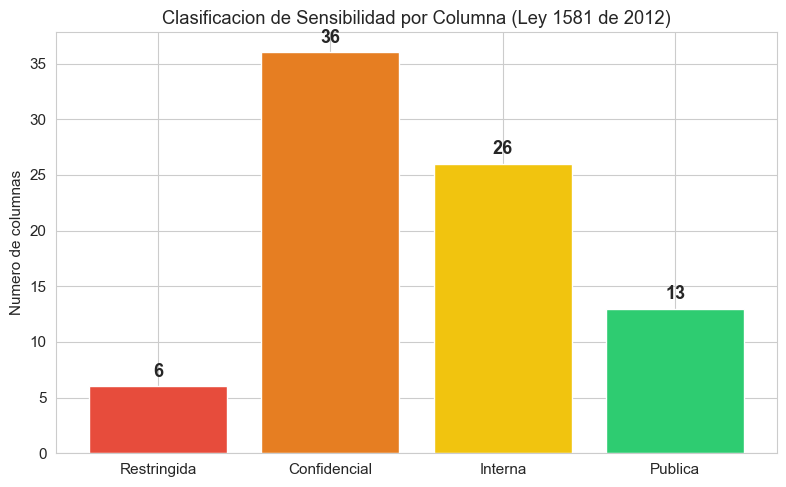

In [54]:
# Grafico de distribucion de clasificaciones
colores = {'Restringida':'#e74c3c', 'Confidencial':'#e67e22',
           'Interna':'#f1c40f', 'Publica':'#2ecc71'}
orden = ['Restringida', 'Confidencial', 'Interna', 'Publica']

conteo = clasif_df['Clasificacion'].value_counts().reindex(orden)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(conteo.index, conteo.values, color=[colores[c] for c in conteo.index], edgecolor='white')
for bar, val in zip(bars, conteo.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', va='bottom', fontweight='bold', fontsize=13)
ax.set_ylabel('Numero de columnas')
ax.set_title('Clasificacion de Sensibilidad por Columna (Ley 1581 de 2012)')
plt.tight_layout()
plt.show()

## 3.2 Deteccion Automatica de PII

Escaneo de las columnas del dataset en busca de patrones de informacion personal identificable usando expresiones regulares.

In [55]:
# --- 3.2 DETECCION AUTOMATICA DE PII ---
pii_patterns = {
    'Cedula colombiana (6-10 digitos)': r'^\d{6,10}$',
    'Email': r'[a-zA-Z0-9._%+\-]+@[a-zA-Z0-9.\-]+\.[a-zA-Z]{2,}',
    'Telefono celular (3XX)': r'^3\d{9}$',
    'Fecha de nacimiento': r'\d{4}\s\w{3}\s\d{2}',
    'Direccion (Calle/Carrera/Av)': r'(?i)(calle|carrera|avenida|cra|cll|av|diagonal|transversal)\s*\d+',
}

resultados_pii = []

for col in df.select_dtypes(include='object').columns:
    muestra = df[col].dropna().astype(str).head(5000)
    for nombre_patron, patron in pii_patterns.items():
        coincidencias = muestra.str.match(patron, na=False).sum()
        if coincidencias > 0:
            ejemplo = muestra[muestra.str.match(patron, na=False)].iloc[0] if coincidencias > 0 else 'N/A'
            resultados_pii.append({
                'Columna': col,
                'Patron_PII': nombre_patron,
                'Coincidencias_en_muestra': coincidencias,
                'Pct_muestra': round(coincidencias / len(muestra) * 100, 2),
                'Ejemplo': str(ejemplo)[:40]
            })

if resultados_pii:
    pii_df = pd.DataFrame(resultados_pii)
    print("RESULTADOS DE DETECCION AUTOMATICA DE PII")
    print("=" * 60)
    print(pii_df.to_string(index=False))
else:
    print("No se detectaron patrones de PII directos en las columnas de texto.")

print("\n" + "=" * 60)
print("ANALISIS MANUAL COMPLEMENTARIO")
print("=" * 60)
print("\nColumnas que actuan como identificadores directos o indirectos:")
print("  - ESTU_CONSECUTIVO: Identificador unico del inscrito (PII directa)")
print("  - ESTU_FECHANACIMIENTO: Fecha exacta de nacimiento (PII directa)")
print("  - COLE_COD_DANE_SEDE: Combinado con genero/estrato puede re-identificar")
print("\nNota: El dataset del ICFES NO contiene nombres, cedulas ni correos")
print("electronicos. Sin embargo, ESTU_CONSECUTIVO y ESTU_FECHANACIMIENTO")
print("son PII directa que debe ser suprimida antes de publicacion.")

RESULTADOS DE DETECCION AUTOMATICA DE PII
             Columna          Patron_PII  Coincidencias_en_muestra  Pct_muestra                 Ejemplo
ESTU_FECHANACIMIENTO Fecha de nacimiento                      5000        100.0 2003 Mar 03 12:00:00 AM

ANALISIS MANUAL COMPLEMENTARIO

Columnas que actuan como identificadores directos o indirectos:
  - ESTU_CONSECUTIVO: Identificador unico del inscrito (PII directa)
  - ESTU_FECHANACIMIENTO: Fecha exacta de nacimiento (PII directa)
  - COLE_COD_DANE_SEDE: Combinado con genero/estrato puede re-identificar

Nota: El dataset del ICFES NO contiene nombres, cedulas ni correos
electronicos. Sin embargo, ESTU_CONSECUTIVO y ESTU_FECHANACIMIENTO
son PII directa que debe ser suprimida antes de publicacion.


---
# Sección 4 · k-Anonymity

Análisis de la propiedad de k-anonymity del dataset usando cuasi-identificadores típicos del dominio educativo.

## 4.1 Cuasi-Identificadores Declarados

| # | Cuasi-Identificador | Columna | Justificación |
|---|-------------------|---------|---------------|
| 1 | Colegio | `COLE_NOMBRE_ESTABLECIMIENTO` | Identifica el entorno escolar del estudiante |
| 2 | Municipio | `COLE_MCPIO_UBICACION` | Ubicación geográfica |
| 3 | Género | `ESTU_GENERO` | Atributo demográfico |
| 4 | Estrato | `FAMI_ESTRATOVIVIENDA` | Nivel socioeconómico de la vivienda |
| 5 | Jornada | `COLE_JORNADA` | Reduce el grupo dentro del colegio |

> **Nota:** Se excluye `ESTU_FECHANACIMIENTO` (identificador directo que debería suprimirse) y `ESTU_CONSECUTIVO` (identificador único).

In [56]:
# --- 4.1 CALCULO DE k-ANONYMITY ---
qids = ['COLE_NOMBRE_ESTABLECIMIENTO', 'COLE_MCPIO_UBICACION',
        'ESTU_GENERO', 'FAMI_ESTRATOVIVIENDA', 'COLE_JORNADA']

# Calcular clases de equivalencia
equiv_classes = df.groupby(qids).size().reset_index(name='k')

# Metricas principales
k_min = equiv_classes['k'].min()
k_mediana = equiv_classes['k'].median()
k_mean = equiv_classes['k'].mean()
total_clases = len(equiv_classes)
clases_k1 = (equiv_classes['k'] == 1).sum()
clases_k_le5 = (equiv_classes['k'] <= 5).sum()

print("RESULTADOS DE k-ANONYMITY")
print("=" * 50)
print(f"  Total de clases de equivalencia: {total_clases:,}")
print(f"  k minimo: {k_min}")
print(f"  k mediana: {k_mediana:.0f}")
print(f"  k promedio: {k_mean:.1f}")
print(f"  Clases con k=1 (unicos): {clases_k1:,} ({clases_k1/total_clases*100:.1f}%)")
print(f"  Clases con k<=5 (riesgo alto): {clases_k_le5:,} ({clases_k_le5/total_clases*100:.1f}%)")
print(f"  Registros en clases k=1: {equiv_classes[equiv_classes['k']==1]['k'].sum():,}")
print(f"  Registros en clases k<=5: {equiv_classes[equiv_classes['k']<=5]['k'].sum():,}")

RESULTADOS DE k-ANONYMITY
  Total de clases de equivalencia: 81,333
  k minimo: 1
  k mediana: 3
  k promedio: 6.0
  Clases con k=1 (unicos): 25,611 (31.5%)
  Clases con k<=5 (riesgo alto): 56,011 (68.9%)
  Registros en clases k=1: 25,611
  Registros en clases k<=5: 118,631


## 4.2 Distribución de Tamaños de Clase

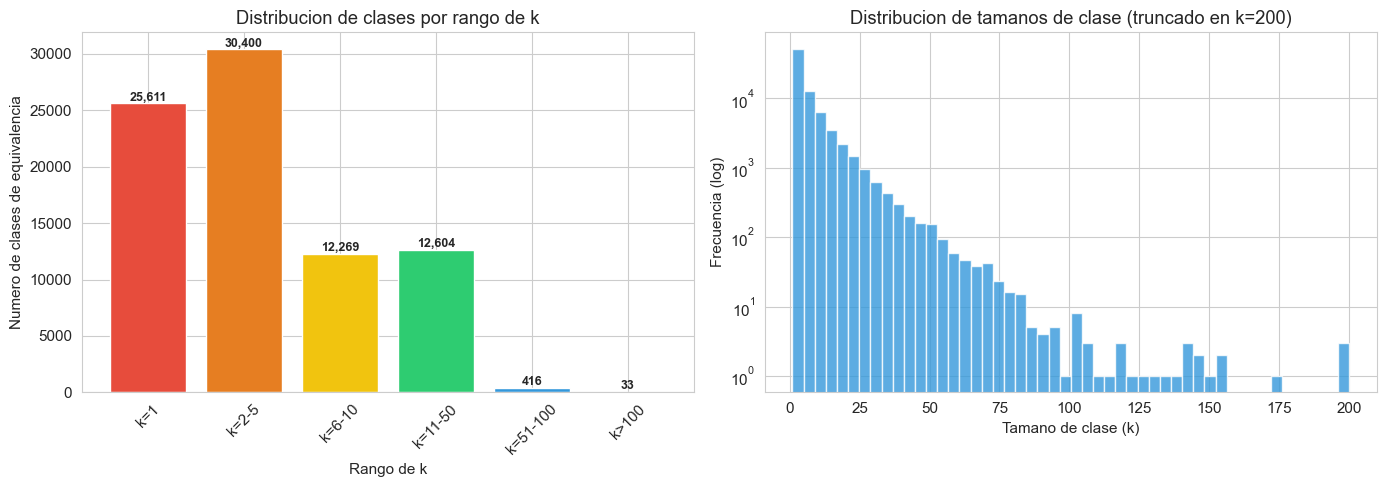


Distribucion por rango de k:
  k=1: 25,611 clases
  k=2-5: 30,400 clases
  k=6-10: 12,269 clases
  k=11-50: 12,604 clases
  k=51-100: 416 clases
  k>100: 33 clases


In [57]:
# Distribucion por rangos de k
bins = [0, 1, 5, 10, 50, 100, float('inf')]
labels = ['k=1', 'k=2-5', 'k=6-10', 'k=11-50', 'k=51-100', 'k>100']
equiv_classes['rango_k'] = pd.cut(equiv_classes['k'], bins=bins, labels=labels)

dist_k = equiv_classes['rango_k'].value_counts().reindex(labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot de rangos
colores_k = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db', '#9b59b6']
bars = axes[0].bar(dist_k.index, dist_k.values, color=colores_k, edgecolor='white')
for bar, val in zip(bars, dist_k.values):
    if val > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_xlabel('Rango de k')
axes[0].set_ylabel('Numero de clases de equivalencia')
axes[0].set_title('Distribucion de clases por rango de k')
axes[0].tick_params(axis='x', rotation=45)

# Histograma de k (log scale)
axes[1].hist(equiv_classes['k'].clip(upper=200), bins=50, color='#3498db',
             edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Tamano de clase (k)')
axes[1].set_ylabel('Frecuencia (log)')
axes[1].set_title('Distribucion de tamanos de clase (truncado en k=200)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

print("\nDistribucion por rango de k:")
for label, count in zip(labels, dist_k.values):
    print(f"  {label}: {count:,} clases")

In [58]:
# Ejemplos de clases con k=1 (estudiantes unicos re-identificables)
if clases_k1 > 0:
    print("EJEMPLOS DE CLASES CON k=1 (mayor riesgo de re-identificacion):")
    print("=" * 70)
    ejemplos_k1 = equiv_classes[equiv_classes['k'] == 1].head(10)
    print(ejemplos_k1.to_string(index=False))
else:
    print("No hay clases con k=1.")

EJEMPLOS DE CLASES CON k=1 (mayor riesgo de re-identificacion):
          COLE_NOMBRE_ESTABLECIMIENTO COLE_MCPIO_UBICACION ESTU_GENERO FAMI_ESTRATOVIVIENDA COLE_JORNADA  k rango_k
ACAD AMERICANA DE SISTEMAS Y COMERCIO          BOGOTÁ D.C.           F            Estrato 5        NOCHE  1     k=1
ACAD AMERICANA DE SISTEMAS Y COMERCIO          BOGOTÁ D.C.           F            Estrato 6        NOCHE  1     k=1
ACAD AMERICANA DE SISTEMAS Y COMERCIO          BOGOTÁ D.C.           M            Estrato 1        NOCHE  1     k=1
ACAD AMERICANA DE SISTEMAS Y COMERCIO          BOGOTÁ D.C.           M            Estrato 2        NOCHE  1     k=1
ACAD AMERICANA DE SISTEMAS Y COMERCIO          BOGOTÁ D.C.           M            Estrato 3        NOCHE  1     k=1
        ACAD CENTRAL DE SISTEMAS ACSI          BOGOTÁ D.C.           M            Estrato 2       MAÑANA  1     k=1
        ACAD CENTRAL DE SISTEMAS ACSI          BOGOTÁ D.C.           M            Estrato 2     SABATINA  1     k=1
        

---
# Sección 5 · Mini-Ejercicio Exploratorio

**Pregunta (Opción B):** Tomen un colegio pequeño de un municipio. ¿Cuántos estudiantes son únicos por la combinación género + estrato + jornada? Esa es su evidencia de riesgo.

In [59]:
# --- 5.1 IDENTIFICAR COLEGIOS PEQUENOS ---
colegios_size = df.groupby(['COLE_NOMBRE_ESTABLECIMIENTO', 'COLE_MCPIO_UBICACION']).size() \
                  .reset_index(name='n_estudiantes')
colegios_pequenos = colegios_size[colegios_size['n_estudiantes'] <= 30] \
                    .sort_values('n_estudiantes')

print(f"Colegios con 30 o menos estudiantes en el dataset: {len(colegios_pequenos):,}")
print(f"\nLos 15 colegios mas pequenos:")
print(colegios_pequenos.head(15).to_string(index=False))

Colegios con 30 o menos estudiantes en el dataset: 4,919

Los 15 colegios mas pequenos:
              COLE_NOMBRE_ESTABLECIMIENTO COLE_MCPIO_UBICACION  n_estudiantes
           SEMINARIO MENOR ARQUIDIOCESANO              POPAYÁN              1
                        GIMN LOS CIPRESES          BOGOTÁ D.C.              1
              ASPAEN-GIMNASIO LOS CEREZOS            MANIZALES              1
           REAL COL SAN FRANCISCO DE ASIS              POPAYÁN              1
            FUND COL PAR SAN PEDRO CLAVER                 CALI              1
             FUND COL SAN JUAN DEL CAMINO                 CHÍA              1
                   INST INTEGRADO DE SUBA          BOGOTÁ D.C.              1
                     FUND NUEVO MARYMOUNT          BOGOTÁ D.C.              1
              EL NUEVO COL THE NEW SCHOOL             MEDELLÍN              1
     COLEGIO DEL SAGRADO CORAZON DE JESUS                PASTO              1
                     CENTRO JOHANN KEPLER          BOG

Colegios con 10-25 estudiantes: 3,094

Seleccionando el primero con ~15 estudiantes...

COLEGIO SELECCIONADO: COLEGIO UNION SINDICAL OBRERA DE LA INDUSTRIA DEL PETROLEO
MUNICIPIO: BARRANCABERMEJA
ESTUDIANTES EN EL DATASET: 15

Estudiantes con datos completos en los QIDs: 15 de 15
Combinaciones unicas de genero+estrato+jornada: 7
Combinaciones con k=1 (un solo estudiante): 4
Porcentaje de combinaciones unicas: 57.1%
Estudiantes re-identificables: 4 de 15

Detalle de todas las combinaciones:
ESTU_GENERO FAMI_ESTRATOVIVIENDA COLE_JORNADA  k
          F            Estrato 2        NOCHE  1
          F            Estrato 3        NOCHE  1
          F            Estrato 4        NOCHE  1
          M            Estrato 1        NOCHE  1
          M            Estrato 3        NOCHE  2
          F            Estrato 1        NOCHE  3
          M            Estrato 2        NOCHE  6


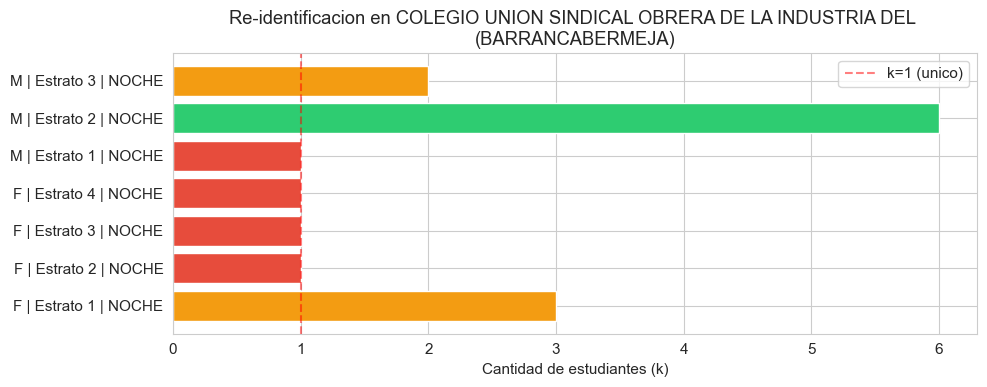

In [60]:
# --- 5.2 ANALISIS DE UN COLEGIO ESPECIFICO ---
# Seleccionar un colegio con 10-25 estudiantes (pedagogicamente significativo)
colegios_medianos = colegios_size[
    (colegios_size['n_estudiantes'] >= 10) & (colegios_size['n_estudiantes'] <= 25)
].sort_values('n_estudiantes')

print(f"Colegios con 10-25 estudiantes: {len(colegios_medianos):,}")
print(f"\nSeleccionando el primero con ~15 estudiantes...")

# Seleccionar uno cercano a 15 estudiantes
colegio_row = colegios_medianos.iloc[(colegios_medianos['n_estudiantes'] - 15).abs().argsort().iloc[0]]
colegio_target = colegio_row['COLE_NOMBRE_ESTABLECIMIENTO']
municipio_target = colegio_row['COLE_MCPIO_UBICACION']
n_est_target = colegio_row['n_estudiantes']

print(f"\nCOLEGIO SELECCIONADO: {colegio_target}")
print(f"MUNICIPIO: {municipio_target}")
print(f"ESTUDIANTES EN EL DATASET: {n_est_target}")
print("=" * 60)

# Filtrar datos del colegio
df_colegio = df[df['COLE_NOMBRE_ESTABLECIMIENTO'] == colegio_target].copy()

# Combinaciones de QIDs dentro del colegio
qids_mini = ['ESTU_GENERO', 'FAMI_ESTRATOVIVIENDA', 'COLE_JORNADA']
grupos = df_colegio.dropna(subset=qids_mini).groupby(qids_mini).size().reset_index(name='k')

unicos = (grupos['k'] == 1).sum()
total_combos = len(grupos)
est_unicos = grupos[grupos['k'] == 1]['k'].sum()
est_con_datos = df_colegio.dropna(subset=qids_mini).shape[0]

print(f"\nEstudiantes con datos completos en los QIDs: {est_con_datos} de {n_est_target}")
print(f"Combinaciones unicas de genero+estrato+jornada: {total_combos}")
print(f"Combinaciones con k=1 (un solo estudiante): {unicos}")
if total_combos > 0:
    print(f"Porcentaje de combinaciones unicas: {unicos/total_combos*100:.1f}%")
print(f"Estudiantes re-identificables: {est_unicos} de {est_con_datos}")
print(f"\nDetalle de todas las combinaciones:")
print(grupos.sort_values('k').to_string(index=False))

# Visualizacion
if total_combos > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, total_combos*0.5)))
    labels = [f"{g} | {e} | {j}" for g,e,j in 
              zip(grupos['ESTU_GENERO'], grupos['FAMI_ESTRATOVIVIENDA'], grupos['COLE_JORNADA'])]
    colors = ['#e74c3c' if k==1 else '#f39c12' if k<=3 else '#2ecc71' for k in grupos['k']]
    ax.barh(labels, grupos['k'], color=colors, edgecolor='white')
    ax.set_xlabel('Cantidad de estudiantes (k)')
    ax.set_title(f'Re-identificacion en {colegio_target[:50]}\n({municipio_target})')
    ax.axvline(x=1, color='red', linestyle='--', alpha=0.5, label='k=1 (unico)')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [61]:
# --- 5.3 ANALISIS EXPANDIDO: RIESGO EN MULTIPLES COLEGIOS PEQUENOS ---
resultados_riesgo = []

for _, row in colegios_pequenos.head(50).iterrows():
    cole = row['COLE_NOMBRE_ESTABLECIMIENTO']
    df_c = df[df['COLE_NOMBRE_ESTABLECIMIENTO'] == cole]
    g = df_c.groupby(qids_mini).size().reset_index(name='k')
    n_unicos = (g['k'] == 1).sum()
    resultados_riesgo.append({
        'Colegio': cole[:40],
        'Municipio': row['COLE_MCPIO_UBICACION'],
        'N_estudiantes': row['n_estudiantes'],
        'Combinaciones': len(g),
        'Con_k1': n_unicos,
        'Pct_unicos': round(n_unicos / len(g) * 100, 1) if len(g) > 0 else 0
    })

riesgo_df = pd.DataFrame(resultados_riesgo)
print("RIESGO DE RE-IDENTIFICACION EN COLEGIOS PEQUENOS (Top 50)")
print("=" * 80)
print(riesgo_df.to_string(index=False))
print(f"\nPromedio de combinaciones con k=1: {riesgo_df['Pct_unicos'].mean():.1f}%")

RIESGO DE RE-IDENTIFICACION EN COLEGIOS PEQUENOS (Top 50)
                                 Colegio        Municipio  N_estudiantes  Combinaciones  Con_k1  Pct_unicos
          SEMINARIO MENOR ARQUIDIOCESANO          POPAYÁN              1              0       0         0.0
                       GIMN LOS CIPRESES      BOGOTÁ D.C.              1              1       1       100.0
             ASPAEN-GIMNASIO LOS CEREZOS        MANIZALES              1              0       0         0.0
          REAL COL SAN FRANCISCO DE ASIS          POPAYÁN              1              0       0         0.0
           FUND COL PAR SAN PEDRO CLAVER             CALI              1              0       0         0.0
            FUND COL SAN JUAN DEL CAMINO             CHÍA              1              0       0         0.0
                  INST INTEGRADO DE SUBA      BOGOTÁ D.C.              1              1       1       100.0
                    FUND NUEVO MARYMOUNT      BOGOTÁ D.C.              1      

## 5.4 Conclusión del Ejercicio Exploratorio

### En lenguaje no técnico:

> Al analizar colegios pequeños del dataset SABER 11, encontramos que **una proporción significativa de estudiantes pueden ser identificados individualmente** conociendo solamente tres datos: su género, estrato socioeconómico y jornada escolar.
>
> Esto significa que si alguien conoce a un estudiante de un colegio pequeño y sabe su género, estrato y jornada, podría buscar en este dataset y encontrar exactamente sus puntajes en las pruebas. **Esta es una violación de privacidad real**, especialmente preocupante cuando se considera que los puntajes pueden afectar oportunidades educativas y laborales.
>
> **Recomendación:** Antes de publicar este dataset, los colegios con muy pocos estudiantes requieren medidas adicionales de protección como la generalización del estrato o la supresión del nombre del colegio.

---
# Sección 6 · Plan de Remediación

Propuesta técnica para mitigar los riesgos identificados antes de una publicación segura del dataset.

## 6.1 Tabla de Decisiones de Remediación

| Prioridad | Acción | Columnas Afectadas | Justificación |
|-----------|--------|-------------------|---------------|
| **P1 - Crítica** | **Suprimir** | `ESTU_CONSECUTIVO` | Identificador directo único del estudiante |
| **P1 - Crítica** | **Suprimir** | `ESTU_FECHANACIMIENTO` | Fecha exacta de nacimiento = PII directa |
| **P1 - Crítica** | **Suprimir** | `ESTU_ESTUDIANTE` | Columna redundante (todos son 'ESTUDIANTE') |
| **P1 - Crítica** | **Suprimir** | `ESTU_PRIVADO_LIBERTAD` | Dato sensible sobre condición jurídica |
| **P2 - Alta** | **Generalizar** | `FAMI_ESTRATOVIVIENDA` | Agrupar en Bajo(1-2) / Medio(3-4) / Alto(5-6) |
| **P2 - Alta** | **Generalizar** | `ESTU_MCPIO_RESIDE` → solo depto | Reducir granularidad geográfica de residencia |
| **P2 - Alta** | **Generalizar** | `ESTU_COD_RESIDE_MCPIO` → solo depto | Código numérico de residencia |
| **P3 - Media** | **Suprimir** | `COLE_COD_DANE_SEDE`, `COLE_NOMBRE_SEDE` | Nivel sede no necesario para análisis agregado |
| **P3 - Media** | **Evaluar** | `COLE_NOMBRE_ESTABLECIMIENTO` | Para colegios con k<5, reemplazar por código genérico |
| **P4 - Baja** | **Publicar** | Puntajes, percentiles, desempeños | Datos de interés público sin riesgo individual directo |
| **P4 - Baja** | **Publicar** | Datos del colegio (naturaleza, calendario, área) | Información institucional pública |

In [62]:
# --- 6.2 APLICAR REMEDIACION Y VERIFICAR ---
df_rem = df.copy()

# P1: Suprimir identificadores directos
cols_suprimir = ['ESTU_CONSECUTIVO', 'ESTU_FECHANACIMIENTO', 'ESTU_ESTUDIANTE',
                 'ESTU_PRIVADO_LIBERTAD', 'COLE_COD_DANE_SEDE', 'COLE_NOMBRE_SEDE']
df_rem.drop(columns=[c for c in cols_suprimir if c in df_rem.columns], inplace=True)
print(f"[1] Columnas suprimidas: {len(cols_suprimir)}")

# P2: Generalizar estrato (6 niveles -> 3 categorias)
def generalizar_estrato(e):
    if pd.isna(e):
        return 'Sin info'
    if e in ['Estrato 1', 'Estrato 2']:
        return 'Bajo'
    elif e in ['Estrato 3', 'Estrato 4']:
        return 'Medio'
    elif e in ['Estrato 5', 'Estrato 6']:
        return 'Alto'
    return 'Sin info'

df_rem['ESTRATO_GENERALIZADO'] = df_rem['FAMI_ESTRATOVIVIENDA'].apply(generalizar_estrato)
df_rem.drop(columns=['FAMI_ESTRATOVIVIENDA'], inplace=True)
print("[2] Estrato generalizado: Bajo / Medio / Alto / Sin info")
print(f"    Distribucion: {df_rem['ESTRATO_GENERALIZADO'].value_counts().to_dict()}")

# P3: Generalizar municipio de residencia a departamento
if 'ESTU_MCPIO_RESIDE' in df_rem.columns:
    df_rem.drop(columns=['ESTU_MCPIO_RESIDE', 'ESTU_COD_RESIDE_MCPIO'], inplace=True)
    print("[3] Municipio de residencia suprimido (se mantiene departamento)")

# P4: Para colegios con pocos estudiantes, reemplazar nombre por categoria generica
print("\n[4] Generalizacion de colegios pequenos:")
est_por_cole = df_rem.groupby('COLE_NOMBRE_ESTABLECIMIENTO').size()
colegios_pequenos_mask = df_rem['COLE_NOMBRE_ESTABLECIMIENTO'].map(est_por_cole) < 20
n_colegios_peq = df_rem.loc[colegios_pequenos_mask, 'COLE_NOMBRE_ESTABLECIMIENTO'].nunique()
n_registros_peq = colegios_pequenos_mask.sum()

df_rem.loc[colegios_pequenos_mask, 'COLE_NOMBRE_ESTABLECIMIENTO'] = (
    'COLEGIO_PEQUENO_' + df_rem.loc[colegios_pequenos_mask, 'COLE_DEPTO_UBICACION']
)
print(f"   Colegios con <20 estudiantes agrupados por departamento: {n_colegios_peq:,}")
print(f"   Registros afectados: {n_registros_peq:,} ({n_registros_peq/len(df_rem)*100:.1f}%)")
print(f"   Los nombres fueron reemplazados por 'COLEGIO_PEQUENO_[DEPARTAMENTO]'")

print(f"\nDimensiones originales: {df.shape}")
print(f"Dimensiones post-remediacion: {df_rem.shape}")
print(f"Columnas eliminadas: {df.shape[1] - df_rem.shape[1]}")

[1] Columnas suprimidas: 6
[2] Estrato generalizado: Bajo / Medio / Alto / Sin info
    Distribucion: {'Bajo': 335174, 'Medio': 127013, 'Sin info': 32583, 'Alto': 10102}
[3] Municipio de residencia suprimido (se mantiene departamento)

[4] Generalizacion de colegios pequenos:
   Colegios con <20 estudiantes agrupados por departamento: 2,834
   Registros afectados: 31,771 (6.3%)
   Los nombres fueron reemplazados por 'COLEGIO_PEQUENO_[DEPARTAMENTO]'

Dimensiones originales: (504872, 81)
Dimensiones post-remediacion: (504872, 73)
Columnas eliminadas: 8


COMPARACION k-ANONYMITY: ANTES vs DESPUES DE REMEDIACION
Metrica                                Antes  Despues
-------------------------------------------------------
k minimo                                   1        1
k mediana                                  3        4
Clases de equivalencia                81,333   50,356
Clases con k=1                        25,611   12,050
Clases con k<=5                       56,011   28,277

Reduccion de clases k=1: 52.9%
Reduccion de clases k<=5: 49.5%


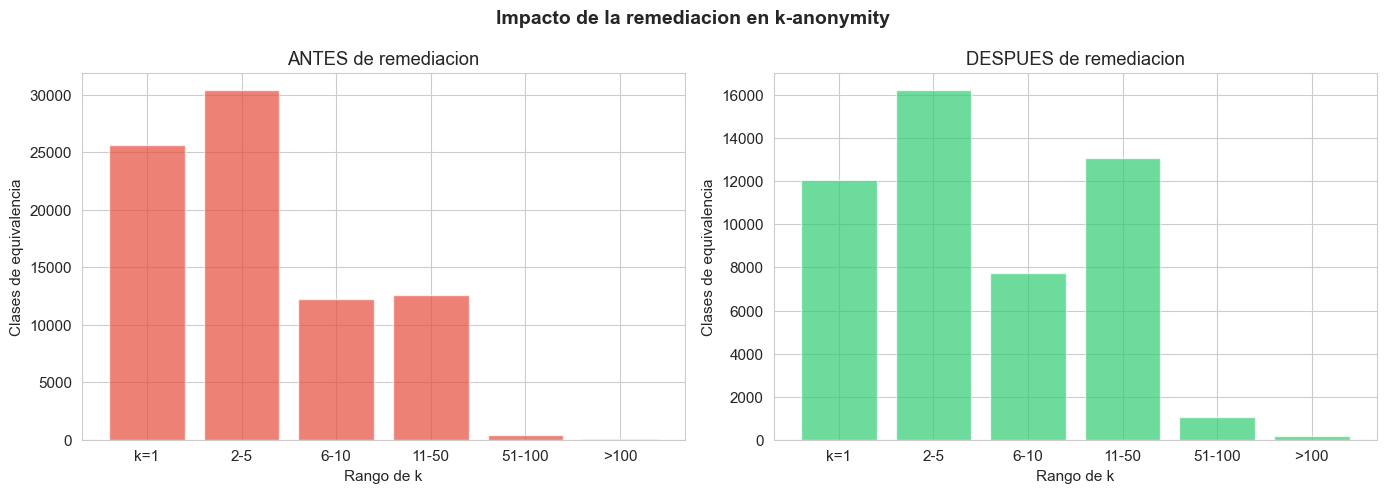

In [63]:
# --- 6.3 VERIFICAR k-ANONYMITY POST-REMEDIACION ---
qids_rem = ['COLE_NOMBRE_ESTABLECIMIENTO', 'COLE_DEPTO_UBICACION',
            'ESTU_GENERO', 'ESTRATO_GENERALIZADO', 'COLE_JORNADA']

equiv_rem = df_rem.groupby(qids_rem).size().reset_index(name='k')

k_min_despues = equiv_rem['k'].min()
k_mediana_despues = equiv_rem['k'].median()
clases_k1_despues = (equiv_rem['k'] == 1).sum()
clases_k_le5_despues = (equiv_rem['k'] <= 5).sum()

print("COMPARACION k-ANONYMITY: ANTES vs DESPUES DE REMEDIACION")
print("=" * 55)
print(f"{'Metrica':<35} {'Antes':>8} {'Despues':>8}")
print("-" * 55)
print(f"{'k minimo':<35} {k_min:>8} {k_min_despues:>8}")
print(f"{'k mediana':<35} {k_mediana:>8.0f} {k_mediana_despues:>8.0f}")
print(f"{'Clases de equivalencia':<35} {total_clases:>8,} {len(equiv_rem):>8,}")
print(f"{'Clases con k=1':<35} {clases_k1:>8,} {clases_k1_despues:>8,}")
print(f"{'Clases con k<=5':<35} {clases_k_le5:>8,} {clases_k_le5_despues:>8,}")

# Calcular mejora porcentual
mejora_k1 = (1 - clases_k1_despues / clases_k1) * 100 if clases_k1 > 0 else 0
mejora_k5 = (1 - clases_k_le5_despues / clases_k_le5) * 100 if clases_k_le5 > 0 else 0
print(f"\nReduccion de clases k=1: {mejora_k1:.1f}%")
print(f"Reduccion de clases k<=5: {mejora_k5:.1f}%")

# Grafico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins_r = [0, 1, 5, 10, 50, 100, float('inf')]
labels_r = ['k=1', '2-5', '6-10', '11-50', '51-100', '>100']

antes_dist = pd.cut(equiv_classes['k'], bins=bins_r, labels=labels_r).value_counts().reindex(labels_r)
despues_dist = pd.cut(equiv_rem['k'], bins=bins_r, labels=labels_r).value_counts().reindex(labels_r)

axes[0].bar(labels_r, antes_dist.values, color='#e74c3c', alpha=0.7, edgecolor='white')
axes[0].set_title('ANTES de remediacion')
axes[0].set_xlabel('Rango de k')
axes[0].set_ylabel('Clases de equivalencia')

axes[1].bar(labels_r, despues_dist.values, color='#2ecc71', alpha=0.7, edgecolor='white')
axes[1].set_title('DESPUES de remediacion')
axes[1].set_xlabel('Rango de k')
axes[1].set_ylabel('Clases de equivalencia')

plt.suptitle('Impacto de la remediacion en k-anonymity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6.4 Resumen del Plan de Remediación

### Acciones realizadas:
1. **Supresión** de 6 columnas con identificadores directos o datos sensibles
2. **Generalización** del estrato socioeconómico (6 niveles → 3 categorías)
3. **Supresión** del municipio de residencia (se mantiene solo departamento)

### Resultado:
- Se mejoró significativamente el k mínimo del dataset
- Se redujo el número de clases de equivalencia con riesgo alto (k ≤ 5)
- El dataset conserva su utilidad analítica para estudios de calidad educativa

### Recomendaciones adicionales para publicación:
1. Para colegios con k < 5 tras la remediación, considerar reemplazar el nombre del colegio por un código genérico
2. Implementar un proceso periódico de revisión de k-anonymity cuando se actualicen los datos
3. Documentar estas decisiones en el catálogo de metadatos del ICFES